# ポアソン分布の最尤推定による異常検知

計数データのうち、連続的な観測区間$t$あたりの発生数$x$に異常検知を適用する場合、最尤推定したポアソン分布を正常のモデルとして用いた、教師なし学習による異常検知手法が有用です。

典型例として、時間あたりの故障発生数に異常検知を適用するケースが挙げられます。経過時間を$t$で表したとき、その時間内での故障発生数$x$は、ポアソン分布$Po(x \mid \mu t)$に従います。よって異常検知においても、ポアソン分布を用いてモデリングすることが適切です。

ここでは以下の手順で、ポアソン分布を用いた異常検知をPythonで実装します。

- A. モデルの学習
- B. 推論

今回は題材として、都道府県ごとの面積あたり活火山数データを使用します（[気象庁のサイト](https://www.data.jma.go.jp/vois/data/tokyo/STOCK/souran/main/kakkazanrisut.pdf)から取得）。火山はその場に既に存在しているものであることから、確率的な現象としてモデリングするには不適に見えますが、活火山の定義は「過去1万年以内に噴火した火山」または「現在活発な噴気活動のある火山」であり、確率的に発生する噴火や噴気活動に基づくポアソン分布によるモデリングに適したデータと言えるでしょう。

データの具体例を以下に示します。

```csv
region,prefecture,volcanoes,area
Hokkaido,Hokkaido,20,8.342
Tohoku,Aomori,4,0.965
Tohoku,Akita,2,1.164
Tohoku,Iwate,3,1.528
...
Kyushu,Kumamoto,1,0.741
Kyushu,Miyazaki,0,0.774
Kyushu,Kagoshima,11,0.919
Kyushu,Okinawa,1,0.228
```

`region`列が地方（今回は使用しない）、`prefecture`列が都道府県、`volcanoes`列が活火山数$x$、`area`列が都道府県の面積$t$（単位：万$km^2$）を表しています。先ほどポアソン分布を適用できる典型例として時間あたりの発生数を上げましたが、このような面積$t$あたりの発生数$x$も、ポアソン分布によるモデリングに適した典型例といえます。

今回は北海道、東北、関東、中部地方を学習データ、それ以外の地方を推論データとして用います。

## A. モデルの学習

学習フェーズでは、ポアソン分布の単位区間あたり平均発生数パラメータ$\mu$の推定値$\hat{\mu}$を、最尤推定で求めます。

ここでも二項分布のバスケットボールの例と同様、都道府県ごとの面積あたり活火山発生数$\mu$の真値が異なる、すなわち過分散が発生していることがドメイン知識から想定されます。

そのため、各データをまとめて一つのポアソン分布モデルに当てはめることは、「**すべての都道府県が同じ活火山発生率**$\mu$**を持つ」という仮定**（＝過分散なし）を置くことに相当し、最尤推定で求められる単位区間あたり平均発生数パラメータ$\hat{\mu}$は、全都道府県で共通と仮定した活火山の発生率（発生密度）にあたります。
この仮定で学習したモデルで異常検知された都道府県は、**日本全体の平均と比べて偶然の範囲を超えて活火山の密度が高い**（**または低い**）ことを意味します。

これに対し、**都道府県ごとの真の活火山発生率の違いそのものをモデル化したい場合には、過分散を考慮可能なモデル**を用いることが適切になります。過分散を考慮可能なモデルとして、[こちらで解説する](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/appendix_notes/5_4_Negative_Binomial.md)負の二項分布モデルや、8章で紹介するランダム効果を加えたモデルが挙げられます。

> 注意：**書籍では**「日本全体の1万$km^2$あたり活火山発生数$2.395$個をもつ架空の都道府県」を想定して**人工的に学習データを生成**していました。しかし本ケースでは「すべての都道府県の活火山発生率が一定」という仮定のもとで異常検知を実施するので、**人工データを用意する必要はなく、都道府県ごとの活火山数をそのまま学習データとして用いて問題ありません**。

上記の考え方に基づくポアソン分布モデルの学習スクリプトを、以下のように実装します。

In [4]:
# コード5.3 ポアソン分布の最尤推定による異常検知の実装例（学習）
import pandas as pd
import numpy as np
from scipy import stats

###### 学習データの読み込みと前処理######
# 日本の活火山データ
df = pd.read_csv("./datasets/volcano_prefectures.csv")
df_train = df[df["region"].isin(['Hokkaido','Tohoku','Kanto','Chubu'])] # 対象地域を絞る
t_train = df_train["area"].to_numpy() # 面積t
x_train = df_train["volcanoes"].to_numpy() # 活火山の数x

###### 学習ステップ1. 正常のモデルを作成する######
mu = np.sum(x_train) / np.sum(t_train) # 面積あたり平均発生数パラメータμの最尤推定量

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
# 推論時に都度算出するので、学習時はしきい値を求めない

###### 学習で求めたパラメータを表示######
print(f"mu={mu}")

mu=2.884268717702199


ここで求めた`mu`が、単位区間あたり平均発生数の最尤推定量$\hat{\mu}$となります。学習データに関して、面積$t$を横軸、面積あたり活火山数$\frac{x}{t}$を縦軸にとった散布図をプロットしてみます。

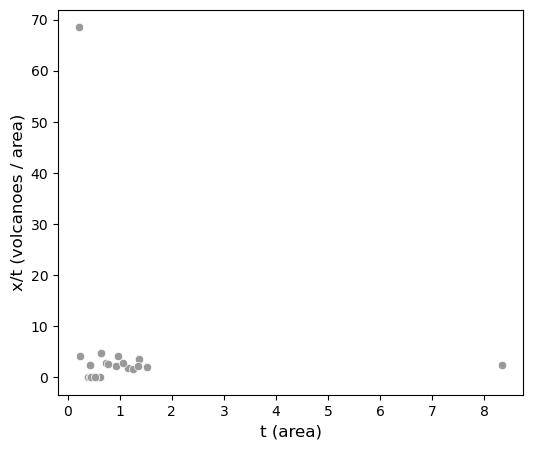

In [6]:
# 面積tと面積あたり活火山数x/tの関係をプロット
import matplotlib.pyplot as plt
import seaborn as sns

# 発生率
ratio_train = x_train / t_train
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
# 分母nと発生率x/nの関係を描画
sns.scatterplot(x=t_train, y=ratio_train, c='#999999', ax=ax)
ax.set_xlabel('t (area)', fontsize=12)
ax.set_ylabel('x/t (volcanoes / area)', fontsize=12)
# グラフを表示
plt.show()

面積$t$が小さいほど面積あたり活火山数$\frac{x}{t}$のばらつきが⼤きく、平均から外れた値が観測されやすいことがわかります。よって面積あたり活火山数$\frac{x}{t}$にしきい値を設けてしまうと、$t$が⼩さい都道府県ほど誤報が増えます。そのため、$t$に合わせてしきい値を変化させる必要があり、それを実現するために$\hat{\mu}$とポアソン分布モデルを用いて、推論時に動的にしきい値を決定します。

なお、今回のデータでは外れ値（左上の点=東京都のデータ、右下の点=北海道のデータ）が全体の分布に大きな影響を与えています。このようなサンプルサイズが小さいデータセットでの極端な外れ値は、特に[過分散をモデリングするケース](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch5_4_Negative_Binomial.ipynb)において問題となりやすいため、モデリング時は十分注意する必要があります。

## B. 推論

学習フェーズで推定したパラメータ$\hat{\mu}$と推論データの面積$t$を用いて、ポアソン分布モデルに基づく以下の式を用いて上下のしきい値$x_{thh},x_{thl}$を求めます。

$x_{thh} = Po_{CDF}^{-1}(1-0.00135 \mid \hat{\mu}t)$

$x_{thl} = Po_{CDF}^{-1}(0.00135 \mid \hat{\mu}t)$

ここで、$Po_{CDF}^{-1}$はポアソン分布の累積分布関数の逆関数を表し、$0.00135$はターゲットとする誤報率$0.0027\div 2$（両側判定なので2で割る必要がある）を表します。

このしきい値を用いて、以下のコードで推論データの都道府県ごとの活火山数$x$に対して異常判定を行います。

In [8]:
# コード5.4 ポアソン分布の最尤推定による異常検知の実装例（推論）
import pandas as pd


###### 学習したパラメータをここに記載
MU=mu # 面積あたり平均発生数パラメータμ

###### 推論データの読み込みと前処理######
# 日本の活火山データ
df = pd.read_csv("./datasets/volcano_prefectures.csv")
df_inference = df[~df["region"].isin(['Hokkaido','Tohoku','Kanto','Chubu'])].copy() # 対象地域を絞る
t_inference = df_inference["area"].to_numpy() # 面積t
x_inference = df_inference["volcanoes"].to_numpy() # 活火山の数x

###### 推論を実行######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# 下側しきい値（ポアソン分布の累積分布関数から計算）
th_lowers = stats.poisson.ppf(TARGET_FP_RATE/2, mu=MU * t_inference)
# 上側しきい値（ポアソン分布の累積分布関数から計算）
th_uppers = stats.poisson.ppf(1 - TARGET_FP_RATE/2, mu=MU * t_inference)
# しきい値により異常の有無を判定
pred = np.where((x_inference < th_lowers) | (x_inference > th_uppers),
                "anomaly", "normal")
# 推論結果を表示（しきい値を超えた都道府県）
df_inference["volcanoes / area"] = x_inference / t_inference # 面積あたり発生数
df_inference["prediction"] = pred
print(df_inference[df_inference["prediction"] == "anomaly"][
      ["prefecture", "volcanoes / area", "volcanoes", "area"]].sort_values(
      "volcanoes / area", ascending=False).reset_index(drop=True))

  prefecture  volcanoes / area  volcanoes   area
0  Kagoshima         11.969532         11  0.919


異常判定のしきい値を超えた都道府県（鹿児島県）は、火山島（陸地面積をあまり増やさずに活火山数が増える）が多いというドメイン知識があり、これが面積あたり活火山数の増加に寄与したと想定されます。

推論の結果、異常と判定される範囲を推論データと重ねて可視化してみます。

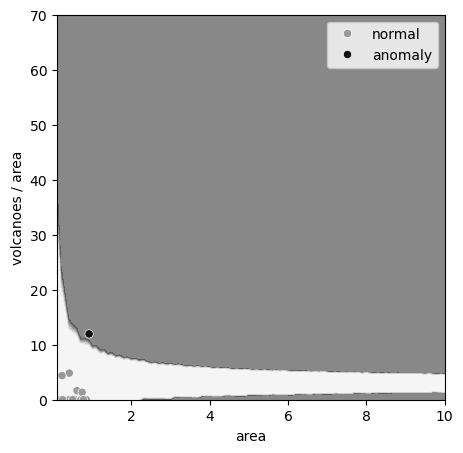

In [9]:
import matplotlib.cm as cm

# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

###### 正常と異常の範囲を色分け ######
# (t,x)格子点を作成
t_grid = np.linspace(0.1, 10, 100)
x_grid = np.arange(0, 700)
T, X = np.meshgrid(t_grid, x_grid)
X_grid = np.c_[T.ravel(), X.ravel()]
ratio_grid = X / T
# 下側しきい値（ポアソン分布の累積分布関数から計算）
th_lowers = stats.poisson.ppf(TARGET_FP_RATE/2, mu=MU * X_grid[:, 0])
# 上側しきい値（ポアソン分布の累積分布関数から計算）
th_uppers = stats.poisson.ppf(1 - TARGET_FP_RATE/2, mu=MU * X_grid[:, 0])
# しきい値判定
pred_grid = np.where((X_grid[:, 1] < th_lowers) | (X_grid[:, 1] > th_uppers),
                     0, 1)
# 正常と異常の境界をプロット
pred_pivot = pred_grid.reshape(T.shape)
ax.contourf(T, ratio_grid, pred_pivot,
            cmap=cm.gray, alpha=0.5)

###### 各データを散布図としてプロット ######
sns.scatterplot(df_inference, x='area', y='volcanoes / area', hue='prediction',
                palette=['#999999', '#111111'], ax=ax)
ax.set_ylim(0, 70)
ax.legend()
# グラフを表示
plt.show()

二項分布の場合と同様に、観測区間（本ケースでは面積）$t$の変化に追従した異常判定が実現できていることがわかります。